# Proyek Missing Values Inputation + Materi Normalisasi data
1. Missing values : menyelesaikan dengan WKNN (manual)  + code menghitung WKNN

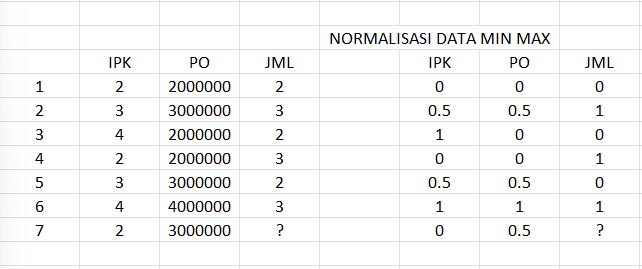



### Tahap 1: Normalisasi Data (Min-Max)

Sebelum menghitung jarak, kita samakan skala data asli menggunakan Normalisasi Min-Max.

**Rumus Normalisasi Min-Max:**
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**1. Tentukan Nilai Min dan Max dari Data Asli (Baris 1-6):**
* **IPK:** $Min = 2$, $Max = 4$
* **PO:** $Min = 2000000$, $Max = 4000000$
* **JML:** $Min = 2$, $Max = 3$

**2. Perhitungan Normalisasi Kolom IPK:**
* Baris 1 (IPK=2): $$IPK_{norm} = \frac{2 - 2}{4 - 2} = 0$$
* Baris 2 (IPK=3): $$IPK_{norm} = \frac{3 - 2}{4 - 2} = 0.5$$
* Baris 3 (IPK=4): $$IPK_{norm} = \frac{4 - 2}{4 - 2} = 1$$
* Baris 4 (IPK=2): $$IPK_{norm} = \frac{2 - 2}{4 - 2} = 0$$
* Baris 5 (IPK=3): $$IPK_{norm} = \frac{3 - 2}{4 - 2} = 0.5$$
* Baris 6 (IPK=4): $$IPK_{norm} = \frac{4 - 2}{4 - 2} = 1$$
* Baris 7 (IPK=2): $$IPK_{norm} = \frac{2 - 2}{4 - 2} = 0$$

**3. Perhitungan Normalisasi Kolom PO:**
* Baris 1 (PO=2000000): $$PO_{norm} = \frac{2000000 - 2000000}{4000000 - 2000000} = 0$$
* Baris 2 (PO=3000000): $$PO_{norm} = \frac{3000000 - 2000000}{4000000 - 2000000} = 0.5$$
* Baris 3 (PO=2000000): $$PO_{norm} = \frac{2000000 - 2000000}{4000000 - 2000000} = 0$$
* Baris 4 (PO=2000000): $$PO_{norm} = \frac{2000000 - 2000000}{4000000 - 2000000} = 0$$
* Baris 5 (PO=3000000): $$PO_{norm} = \frac{3000000 - 2000000}{4000000 - 2000000} = 0.5$$
* Baris 6 (PO=4000000): $$PO_{norm} = \frac{4000000 - 2000000}{4000000 - 2000000} = 1$$
* Baris 7 (PO=3000000): $$PO_{norm} = \frac{3000000 - 2000000}{4000000 - 2000000} = 0.5$$

**4. Perhitungan Normalisasi Kolom JML:**
* Baris 1 (JML=2): $$JML_{norm} = \frac{2 - 2}{3 - 2} = 0$$
* Baris 2 (JML=3): $$JML_{norm} = \frac{3 - 2}{3 - 2} = 1$$
* Baris 3 (JML=2): $$JML_{norm} = \frac{2 - 2}{3 - 2} = 0$$
* Baris 4 (JML=3): $$JML_{norm} = \frac{3 - 2}{3 - 2} = 1$$
* Baris 5 (JML=2): $$JML_{norm} = \frac{2 - 2}{3 - 2} = 0$$
* Baris 6 (JML=3): $$JML_{norm} = \frac{3 - 2}{3 - 2} = 1$$
* Baris 7 (JML=?): Belum diketahui.

---

### Tahap 2: Menghitung WKNN (Mencari "?" pada Tabel Normalisasi)

Kita gunakan tabel yang **sudah dinormalisasi** untuk memprediksi nilai JML baris ke-7.

* **Data Target (Baris 7):** $X_{target} = (0, 0.5)$
* **Data Latih (Baris 1-6):**
    * $X_1 = (0, 0)$, $Y_1 = 0$
    * $X_2 = (0.5, 0.5)$, $Y_2 = 1$
    * $X_3 = (1, 0)$, $Y_3 = 0$
    * $X_4 = (0, 0)$, $Y_4 = 1$
    * $X_5 = (0.5, 0.5)$, $Y_5 = 0$
    * $X_6 = (1, 1)$, $Y_6 = 1$

**Langkah 1: Hitung Jarak Euclidean ($d$)**
Hitung jarak dari $X_{target}$ ke semua data latih: $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$
* $d_1 = \sqrt{(0 - 0)^2 + (0 - 0.5)^2} = 0.5$
* $d_2 = \sqrt{(0.5 - 0)^2 + (0.5 - 0.5)^2} = 0.5$
* $d_3 = \sqrt{(1 - 0)^2 + (0 - 0.5)^2} \approx 1.118$
* $d_4 = \sqrt{(0 - 0)^2 + (0 - 0.5)^2} = 0.5$
* $d_5 = \sqrt{(0.5 - 0)^2 + (0.5 - 0.5)^2} = 0.5$
* $d_6 = \sqrt{(1 - 0)^2 + (1 - 0.5)^2} \approx 1.118$

**Langkah 2: Tentukan Nilai K dan Hitung Bobot ($w$)**
Terdapat **4 data** dengan jarak terdekat yang sama persis (Baris 1, 2, 4, 5 dengan $d = 0.5$). Maka kita gunakan **K = 4**.
Hitung bobot dengan rumus $w = \frac{1}{d}$:
* $w_1 = \frac{1}{0.5} = 2$
* $w_2 = \frac{1}{0.5} = 2$
* $w_4 = \frac{1}{0.5} = 2$
* $w_5 = \frac{1}{0.5} = 2$

**Langkah 3: Hitung Prediksi (Weighted Average)**
$$Prediksi = \frac{\sum (w_i \times Y_i)}{\sum w_i}$$
$$Prediksi = \frac{(2 \times 0) + (2 \times 1) + (2 \times 1) + (2 \times 0)}{2 + 2 + 2 + 2}$$
$$Prediksi = \frac{0 + 2 + 2 + 0}{8} = \frac{4}{8} = 0.5$$

> **Hasil:** Prediksi Normalisasi JML untuk baris ke-7 adalah **0.5**.

---

### Tahap 3: Denormalisasi (Mencari "?" pada Tabel JML Asli)

**Rumus Denormalisasi:**
$$X_{asli} = X_{norm} \times (X_{max} - X_{min}) + X_{min}$$

Masukkan nilai prediksi dan nilai Min/Max dari JML asli:
* $X_{norm} = 0.5$
* $X_{min} = 2$
* $X_{max} = 3$

$$JML_{asli} = 0.5 \times (3 - 2) + 2$$
$$JML_{asli} = 0.5 \times 1 + 2 = 2.5$$

> **Hasil Akhir:** Tanda "?" pada kolom JML asli adalah **2.5**.

---



### Kode Implementasi WKNN Python



In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances

# 1. DATA ASLI
data = pd.DataFrame({
    'IPK': [2, 3, 4, 2, 3, 4, 2],
    'PO': [2000000, 3000000, 2000000, 2000000, 3000000, 4000000, 3000000],
    'JML': [2.0, 3.0, 2.0, 3.0, 2.0, 3.0, np.nan]
})

print("--- 1. DATA ASLI ---")
print(data)
print("\n" + "="*40 + "\n")

# 2. PROSES NORMALISASI MIN-MAX  
scaler_X = MinMaxScaler()
X = data[['IPK', 'PO']]
X_norm = scaler_X.fit_transform(X)

# Normalisasi Target (JML) 
y_train = data['JML'][:6]
jml_min = y_train.min()
jml_max = y_train.max()
y_train_norm = (y_train - jml_min) / (jml_max - jml_min)

df_norm = pd.DataFrame(X_norm, columns=['IPK_Norm', 'PO_Norm'])
df_norm['JML_Norm'] = list(y_train_norm) + [np.nan]

print("--- 2. HASIL NORMALISASI MIN-MAX ---")
print(df_norm)
print("\n" + "="*40 + "\n")

X_train_norm = X_norm[:6]
X_target_norm = X_norm[6:]  

# 3. MENGHITUNG JARAK EUCLIDEAN
distances = euclidean_distances(X_target_norm, X_train_norm)[0]

print("--- 3. JARAK EUCLIDEAN (Target ke Data Latih) ---")
for i, d in enumerate(distances):
    print(f"Jarak ke Baris {i+1}: {d:.4f}")
print("\n" + "="*40 + "\n")

# 4. PERHITUNGAN WKNN MANUAL (K=4)
K = 4
nearest_indices = np.argsort(distances)[:K] # Ambil 4 terdekat

print(f"--- 4. PERHITUNGAN WKNN MANUAL (K={K}) ---")
weights = []
weighted_sum = 0
total_weight = 0

for i in nearest_indices:
    w = 1 / distances[i]
    weights.append(w)

    y_norm_val = y_train_norm[i]
    weighted_sum += w * y_norm_val
    total_weight += w

    print(f"Baris {i+1} -> Jarak: {distances[i]:.4f} | Bobot: {w:.4f} | JML_Norm: {y_norm_val:.1f}")

prediksi_norm = weighted_sum / total_weight
print(f"\n=> Prediksi Normalisasi JML (Baris 7) = {prediksi_norm:.4f}")
print("\n" + "="*40 + "\n")

# 5. DENORMALISASI
print("--- 5. HASIL DENORMALISASI (NILAI ASLI JML) ---")
prediksi_asli = prediksi_norm * (jml_max - jml_min) + jml_min
print(f"=> HASIL AKHIR PREDIKSI JML ASLI: {prediksi_asli:.4f}")

--- 1. DATA ASLI ---
   IPK       PO  JML
0    2  2000000  2.0
1    3  3000000  3.0
2    4  2000000  2.0
3    2  2000000  3.0
4    3  3000000  2.0
5    4  4000000  3.0
6    2  3000000  NaN


--- 2. HASIL NORMALISASI MIN-MAX ---
   IPK_Norm  PO_Norm  JML_Norm
0       0.0      0.0       0.0
1       0.5      0.5       1.0
2       1.0      0.0       0.0
3       0.0      0.0       1.0
4       0.5      0.5       0.0
5       1.0      1.0       1.0
6       0.0      0.5       NaN


--- 3. JARAK EUCLIDEAN (Target ke Data Latih) ---
Jarak ke Baris 1: 0.5000
Jarak ke Baris 2: 0.5000
Jarak ke Baris 3: 1.1180
Jarak ke Baris 4: 0.5000
Jarak ke Baris 5: 0.5000
Jarak ke Baris 6: 1.1180


--- 4. PERHITUNGAN WKNN MANUAL (K=4) ---
Baris 1 -> Jarak: 0.5000 | Bobot: 2.0000 | JML_Norm: 0.0
Baris 2 -> Jarak: 0.5000 | Bobot: 2.0000 | JML_Norm: 1.0
Baris 4 -> Jarak: 0.5000 | Bobot: 2.0000 | JML_Norm: 1.0
Baris 5 -> Jarak: 0.5000 | Bobot: 2.0000 | JML_Norm: 0.0

=> Prediksi Normalisasi JML (Baris 7) = 0.5000


-

# Tugas 2. Normalisasi data (materi)
- macam macam normalisasi data dan beri    contoh hasil normalisasi data
- Gunakan library sklearn untuk melakukan normalisasi data atau membuat fungsi sendiri

# Preprocessing Data

## Normalisasi Data
Normalisasi data adalah teknik *preprocessing* yang digunakan untuk mengubah skala nilai numerik dalam dataset agar berada dalam rentang yang seragam dan sebanding. Tujuan utamanya adalah untuk mencegah fitur (kolom) dengan rentang nilai yang sangat besar mendominasi fitur dengan rentang nilai yang kecil saat algoritma *machine learning* melakukan perhitungan jarak.

Berikut adalah 3 macam normalisasi data yang paling sering digunakan beserta contoh manual dan implementasi kodenya.

---

### 1. Min-Max Normalization

Teknik ini mengubah rentang data agar secara linier masuk ke dalam skala tertentu, secara *default* berada di antara **0 sampai 1**. Angka terkecil di data asli akan menjadi 0, dan angka terbesar akan menjadi 1.

**Rumus:**
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Contoh Perhitungan Manual:**
Misalkan terdapat data Umur: **20, 30, 50**.
* Nilai minimum ($X_{min}$) = 20
* Nilai maksimum ($X_{max}$) = 50

Proses normalisasi:
* Umur **20**: $$X_{norm} = \frac{20 - 20}{50 - 20} = \frac{0}{30} = 0$$
* Umur **30**: $$X_{norm} = \frac{30 - 20}{50 - 20} = \frac{10}{30} \approx 0.333$$
* Umur **50**: $$X_{norm} = \frac{50 - 20}{50 - 20} = \frac{30}{30} = 1$$

**Implementasi Code (Menggunakan library `sklearn`):**

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

 
df_minmax = pd.DataFrame({'Umur': [20, 30, 50]})

print("--- Data Asli ---")
print(df_minmax)

 
scaler_minmax = MinMaxScaler()
df_minmax['Umur_Norm'] = scaler_minmax.fit_transform(df_minmax[['Umur']])

print("--- Hasil Min-Max Normalization ---")
print(df_minmax)

--- Data Asli ---
   Umur
0    20
1    30
2    50
--- Hasil Min-Max Normalization ---
   Umur  Umur_Norm
0    20   0.000000
1    30   0.333333
2    50   1.000000


----
### 2. Z-Score Normalization (Standardization)

Teknik ini mengubah data berdasarkan rata-rata (*mean*) dan standar deviasinya, sehingga data yang baru akan memiliki **rata-rata ($\mu$) = 0** dan **standar deviasi ($\sigma$) = 1**. Teknik ini sangat cocok untuk data yang memiliki banyak nilai pencilan (*outlier*).

**Rumus:**
$$Z = \frac{X - \mu}{\sigma}$$

**Contoh Perhitungan Manual:**
Misalkan terdapat data Nilai: **2, 4, 6**.
* Rata-rata ($\mu$) = 4
* Standar Deviasi ($\sigma$) = 1.633

Proses normalisasi:
* Nilai **2**: $$Z = \frac{2 - 4}{1.633} \approx -1.22$$
* Nilai **4**: $$Z = \frac{4 - 4}{1.633} = 0$$
* Nilai **6**: $$Z = \frac{6 - 4}{1.633} \approx 1.22$$

**Implementasi Code (Menggunakan library `sklearn`):**

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
 
df_zscore = pd.DataFrame({'Nilai': [2, 4, 6]})

print("--- Data Asli ---")
print(df_zscore)

 
scaler_zscore = StandardScaler()
df_zscore['Nilai_Norm'] = scaler_zscore.fit_transform(df_zscore[['Nilai']])

print("-- Hasil Z-Score Normalization ---")
print(df_zscore)

--- Data Asli ---
   Nilai
0      2
1      4
2      6
-- Hasil Z-Score Normalization ---
   Nilai  Nilai_Norm
0      2   -1.224745
1      4    0.000000
2      6    1.224745


---------
### 3. Decimal Scaling Normalization

Teknik ini memindahkan titik desimal (koma) dari suatu nilai berdasarkan jumlah digit dari angka absolut (positif) terbesar di dalam dataset tersebut. Rentang hasil akhirnya akan berada di antara **-1 sampai 1**.

**Rumus:**
$$X_{norm} = \frac{X}{10^j}$$

**Contoh Perhitungan Manual:**
Misalkan terdapat data: **150, 2500, -8500**.
* Angka absolut terbesar adalah **8500**.
* Angka 8500 memiliki **4 digit**, sehingga nilai $j = 4$.
* Nilai pembagi ($10^j$) = $10^4 = 10000$.

Proses normalisasi:
* Nilai **150**: $$X_{norm} = \frac{150}{10000} = 0.015$$
* Nilai **2500**: $$X_{norm} = \frac{2500}{10000} = 0.25$$
* Nilai **-8500**: $$X_{norm} = \frac{-8500}{10000} = -0.85$$

**Implementasi Code (Membuat fungsi sendiri):**
Karena `sklearn` tidak menyediakan fungsi khusus untuk Decimal Scaling (karena operasinya sangat sederhana), kita bisa membuat fungsinya sendiri menggunakan Pandas.

In [24]:
import pandas as pd

 
df_decimal = pd.DataFrame({'Data': [150, 2500, -8500]})

print("--- Data Asli ---")
print(df_decimal)

 
def decimal_scaling(kolom):
    max_abs = kolom.abs().max()      
    j = len(str(int(max_abs)))        
    return kolom / (10**j)             

df_decimal['Data_Norm'] = decimal_scaling(df_decimal['Data'])

print("\n--- Hasil Decimal Scaling Normalization ---")
print(df_decimal)

--- Data Asli ---
   Data
0   150
1  2500
2 -8500

--- Hasil Decimal Scaling Normalization ---
   Data  Data_Norm
0   150      0.015
1  2500      0.250
2 -8500     -0.850
